In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prajwal6362venom/choclate-sales-project/choclate protfolio project - 11.csv


# CHOCLATE SALES ANALYSIS

****Executive Summary****

This report analyzes global chocolate sales data (2022-2025) to identify top-performing products, sales representatives, and regions. The findings highlight significant opportunities for inventory optimization and regional targeting.


**Key Insights**

**Top Salesperson**: Gigi Bohling is the best-performing sales representative, with a total sales volume of 165,725

**Top Product**: Bakery Chips generated the maximum profit 

**Popular Brand**: Milk Bar is the most popular brand, showing high demand and volume 

**Regional Performance**: Australia is the highest contributing region to total sales 

**Profitability Trends**: India and Canada are the leading countries in generating the highest profits  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/prajwal6362venom/choclate-sales-project/choclate protfolio project - 11.csv')
df.head()

,Sales Person,Geography,Product,Amount,Units,cost per unit,Cost,Profit,profit %
0,Ram Mahesh,New Zealand,70% Dark Bites,"$1,624",114,14,"1,652",($28),-2%
1,Brien Boise,USA,Choco Coated Almonds,"$6,706",459,9,"3,970","$2,736",41%
2,Husein Augar,USA,Almond Choco,$959,147,12,"1,746",($787),-82%
3,Carla Molina,Canada,Drinking Coco,"$9,632",288,6,"1,863","$7,769",81%
4,Curtice Advani,UK,White Choc,"$2,100",414,13,"5,444","($3,344)",-159%


**Data Exploration**

In [4]:
# Change the format of the column
df['Amount']= df['Amount'].str.replace("$","",regex = False).str.replace(",", "", regex = False).astype('int')
df['Profit']= df['Profit'].str.replace("$","",regex = False).str.replace(",", "", regex = False).str.replace("(", "", regex = False).str.replace(")", "", regex = False).astype("int")
df['Cost'] = df['Cost'].str.replace(",","", regex=False).astype('int')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   300 non-null    object
 1   Geography      300 non-null    object
 2   Product        300 non-null    object
 3   Amount         300 non-null    int64 
 4   Units          300 non-null    int64 
 5   cost per unit  300 non-null    int64 
 6   Cost           300 non-null    int64 
 7   Profit         300 non-null    int64 
 8   profit %       300 non-null    object
dtypes: int64(5), object(4)
memory usage: 21.2+ KB


In [6]:
# renaming column
df.rename(columns={'Amount': 'Revenue', 'cost per unit': 'Cost_per_unit'}, inplace = True)

In [7]:
#Dropping columns Cost, Profit, Profit%
df.drop(columns = ['Cost','Profit','profit %'],inplace = True)

In [8]:
# Creating a new column Total_Cost,Profit, Profit%
df['Total_Cost'] = df['Cost_per_unit']*df['Units']
df['Profit']= df['Revenue']- df['Total_Cost']
df['Profit%'] = ((df['Profit'] / df['Revenue']) * 100).round(2)

In [9]:
df.nunique()

Sales Person      10
Geography          6
Product           22
Revenue          268
Units            120
Cost_per_unit     12
Total_Cost       214
Profit           295
Profit%          297
dtype: int64

**Visualization**

In [10]:
# Sales Persn performance based on revenue tht they have generated
df.groupby("Sales Person")['Profit'].sum()

Sales Person
Barr Faughny        85114
Brien Boise         52574
Carla Molina        60632
Ches Bonnell        99791
Curtice Advani      69632
Gigi Bohling       134978
Gunar Cockshoot     60121
Husein Augar        89107
Oby Sorrel          47897
Ram Mahesh         101454
Name: Profit, dtype: int64

In [11]:
# Maximum contributio is coming from Australia
df.groupby("Geography")['Revenue'].sum()

Geography
Australia      168679
Canada         237944
India          252469
New Zealand    218813
UK             173530
USA            189434
Name: Revenue, dtype: int64

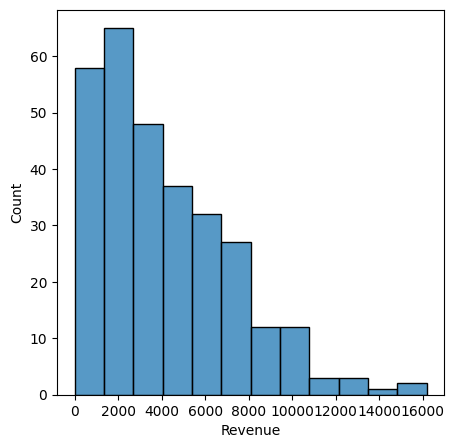

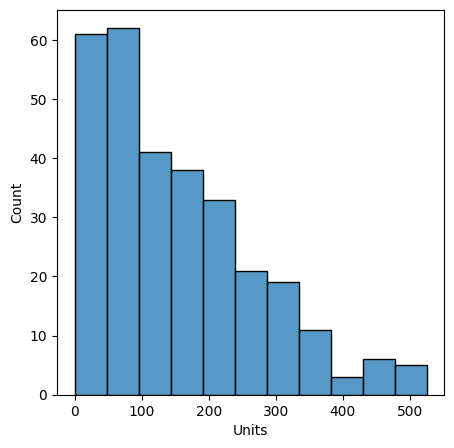

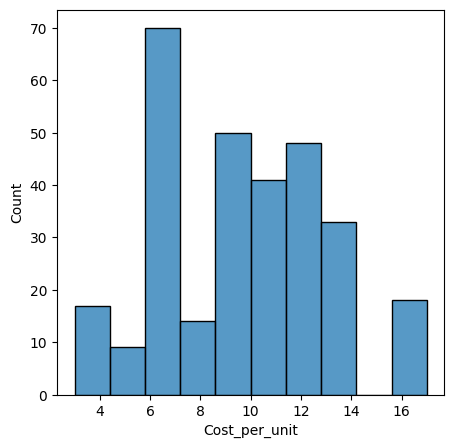

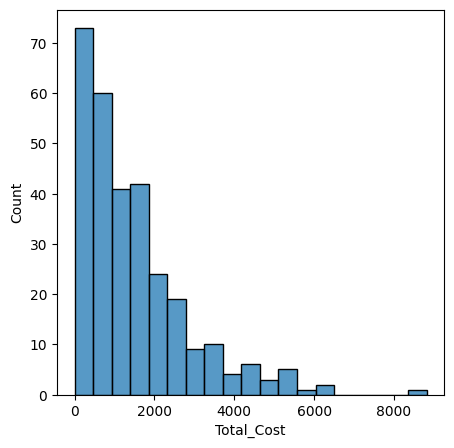

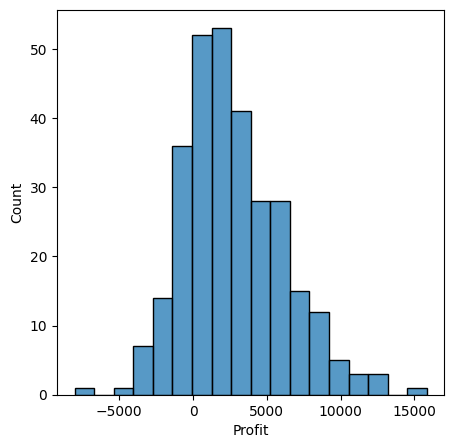

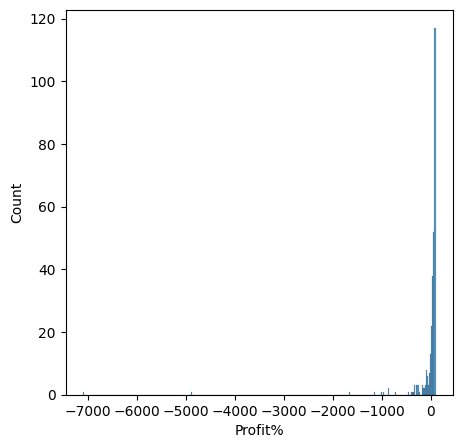

In [12]:
count_plot = df.select_dtypes(['int64','float64'])
for i in count_plot:
    plt.figure(figsize = (5,5))
    sns.histplot(df, x=df[i])
    plt.show('/')

**Insights**

In [13]:
# Which products generate maximum profit
# Overview of data with pivot table.  BAkers chips is givng max profit
pivot_df = pd.pivot_table(df, index='Product', values='Profit', aggfunc='sum')
pivot_df = pivot_df.sort_values(by='Profit', ascending=False)
pivot_df

,Profit
Product,
Baker's Choco Chips,57421
Eclairs,56728
Choco Coated Almonds,51258
Raspberry Choco,50575
Peanut Butter Cubes,46912
Fruit & Nut Bars,45772
After Nines,45763
Mint Chip Choco,42725
Drinking Coco,41638


Text(0.5, 1.0, 'Ranking Sales Person By Profit Earned')

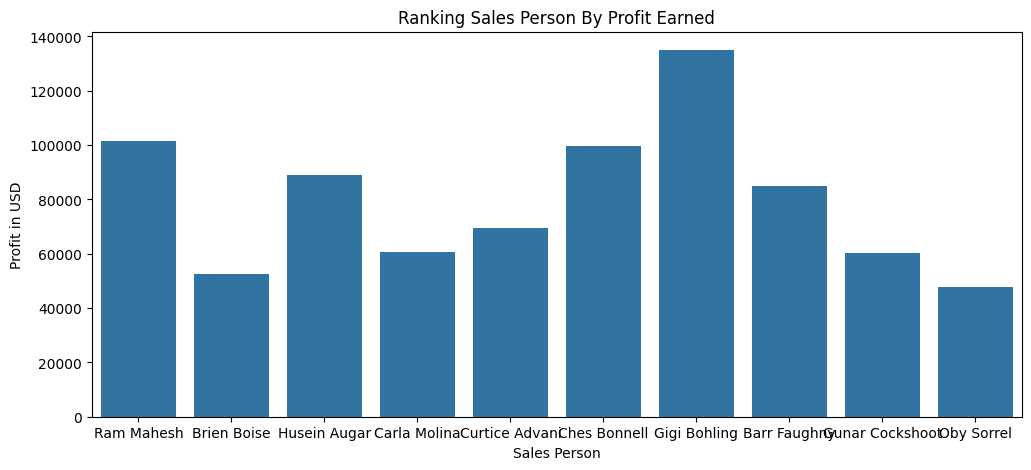

In [14]:
prod_prof = df.groupby("Sales Person")['Profit'].sum()
prod_prof
plt.figure(figsize= (12,5))
sns.barplot(x='Sales Person', y= 'Profit', data=df, estimator= sum, errorbar = None)
plt.ylabel('Profit in USD')
plt.xlabel('Sales Person')
plt.title('Ranking Sales Person By Profit Earned')
# Gigi Bohling is the most profitable salesperson

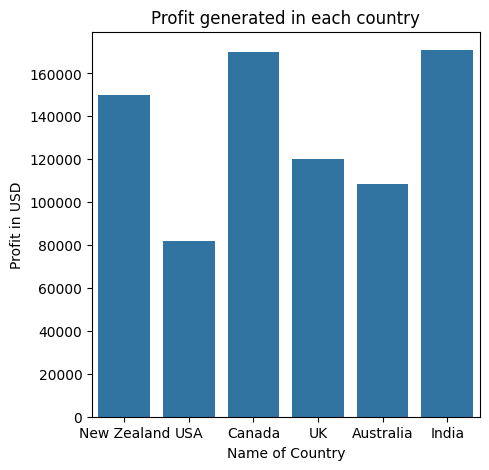

In [15]:
prod_prof = df.groupby("Geography")['Profit'].sum()
plt.figure(figsize =(5,5))
sns.barplot(x= 'Geography', y = 'Profit', data=df, estimator = sum, errorbar = None )
plt.ylabel('Profit in USD')
plt.xlabel('Name of Country')
plt.title('Profit generated in each country')
plt.show()
# India And Canada Generated highest profit

 **The best Sales person by region and overall**

In [16]:
#Overview data by pivot table
pivot_sm = pd.pivot_table(df, values = 'Profit', index = 'Sales Person' , columns = 'Geography')
pivot_sm = pivot_sm.sort_values(by =["Australia",'Canada','India','New Zealand','UK','USA'], ascending = False)
pivot_sm

Geography,Australia,Canada,India,New Zealand,UK,USA
Sales Person,,,,,,
Gunar Cockshoot,7023.000000,2995.800000,2853.750000,1614.750000,1588.500000,412.666667
Gigi Bohling,5654.250000,6013.333333,4185.857143,3262.250000,3270.750000,3474.666667
Husein Augar,3435.333333,4555.000000,4917.666667,1638.714286,2020.333333,809.250000
Carla Molina,2883.000000,3770.428571,1885.800000,1357.500000,3112.000000,1557.400000
Barr Faughny,2719.400000,2510.400000,3158.500000,4585.600000,2860.700000,556.500000
Ches Bonnell,2349.250000,2466.666667,2733.250000,4876.571429,650.000000,2613.142857
Ram Mahesh,1957.714286,2820.600000,2990.333333,5150.500000,3346.800000,2624.142857
Oby Sorrel,1096.250000,1042.200000,2626.200000,1648.333333,7468.500000,1057.600000
Curtice Advani,946.000000,3934.333333,2086.444444,2187.428571,1364.200000,-376.750000


In [17]:
regional_sales = df.groupby(['Geography', 'Sales Person'])['Revenue'].sum().reset_index()
best_by_region = regional_sales.loc[regional_sales.groupby('Geography')['Revenue'].idxmax()]
print(best_by_region)

# Best sales person by region is Gigi Bohling 

      Geography  Sales Person  Revenue
5     Australia  Gigi Bohling    25221
15       Canada  Gigi Bohling    39620
25        India  Gigi Bohling    41559
33  New Zealand  Ches Bonnell    43568
40           UK  Barr Faughny    45752
59          USA    Ram Mahesh    38325


In [18]:
overall_sales = df.groupby('Sales Person')['Revenue'].sum()
best_overall = overall_sales.idxmax()
print(f"Best Overall: {best_overall} with {overall_sales.max()} sales")

Best Overall: Gigi Bohling with 165725 sales


 **The most popular products in each region**

In [19]:
bst_prod = df.groupby(['Product', 'Geography'])['Units'].sum().reset_index()
most_popular = bst_prod.loc[bst_prod.groupby('Geography')['Units'].idxmax()]
most_popular
# Milk Bar is the most popular brand

,Product,Geography,Units
71,Milk Bars,Australia,1158
86,Organic Choco Syrup,Canada,1101
81,Orange Choco,India,987
41,Caramel Stuffed Bars,New Zealand,858
117,White Choc,UK,948
100,Raspberry Choco,USA,912


In [20]:
Actionable Recommendations

**Focus on Top Performer**: Incentivize high-performing employees like Gigi Bohling to maintain high sales volumes.

**Regional Expansion**: Invest more in marketing efforts in India and Canada to maximize profit margins.

**Inventory Optimization**: Ensure steady stock levels for Milk Bar and Bakery Chips to meet high demand. 

SyntaxError: invalid syntax (1003801186.py, line 1)

**Actionable Recommendations**

**Focus on Top Performer**: Incentivize high-performing employees like Gigi Bohling to maintain high sales volumes.

**Regional Expansion**: Invest more in marketing efforts in India and Canada to maximize profit margins.

**Inventory Optimization**: Ensure steady stock levels for Milk Bar and Bakery Chips to meet high demand. 

Actionable Recommendations

**Focus on Top Performer**: Incentivize high-performing employees like Gigi Bohling to maintain high sales volumes.

**Regional Expansion**: Invest more in marketing efforts in India and Canada to maximize profit margins.

**Inventory Optimization**: Ensure steady stock levels for Milk Bar and Bakery Chips to meet high demand. 

In [ ]:
Conclusion

The analysis suggests that focusing on high-margin products like Bakery Chips and leveraging the top-performing sales force in key regions like Australia and India will drive future profitability.


Actionable Recommendations

**Focus on Top Performer**: Incentivize high-performing employees like Gigi Bohling to maintain high sales volumes.

**Regional Expansion**: Invest more in marketing efforts in India and Canada to maximize profit margins.

**Inventory Optimization**: Ensure steady stock levels for Milk Bar and Bakery Chips to meet high demand. 